# 01-6 声音怎么变成 Token

在 [上一节](./01-5-video_to_token.ipynb) 中，我们了解了视频如何通过时间+空间 Patch 变成 Token。那声音呢？声音是一个连续的一维信号（波形），它比图片更难被"切块"。

本节我们将探索 **音频 Token**：声音波形如何被量化为离散的 Token？TTS 又如何从 Token 生成语音？

⏸ 关于全双工多模态交互（同时听和说），我们将在 [下一节](./01-7-full_duplex_multimodal.ipynb) 中用 MiniCPM-o 模型来体验。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()

print("本节只需可视化库，无需加载大模型")

本节只需可视化库，无需加载大模型


## 1. 音频 Token：声音如何被量化？

音频是一个连续的一维信号（波形），它比图片更难被"切块"。音频 Token 的核心挑战是：**如何将连续的波形信号转化为离散的、有限的 Token 序列？**

目前主流的音频 Token 方案有两种：

### 方案一：声学特征 + 离散化（ASR 路线）

1. **分帧**：将音频切成短帧（如 25ms 一帧，步长 10ms）。
2. **提取声学特征**：对每帧做 FFT，得到频谱图（Mel 频谱等）。
3. **离散化**：用声学模型（如 HuBERT）将频谱特征聚类为离散的 Token。

### 方案二：端到端音频编解码器（Codec 路线）

1. **编码器**：将音频压缩为离散的 Codebook 索引（多层 Residual Vector Quantization）。
2. **解码器**：从 Codebook 索引重建音频波形。
3. **优势**：可以同时支持语音识别（ASR）和语音合成（TTS）。

Qwen3.5-Omni 采用的就是 Codec 路线，它的 **Thinker-Talker** 架构非常精妙：
- **Thinker**：类似于"大脑"，负责理解音频内容，输出文本思维。
- **Talker**：类似于"嘴巴"，将 Thinker 的输出转化为语音 Token，再通过解码器生成波形。

让我们用代码来直观感受音频的"分帧"和"量化"过程：

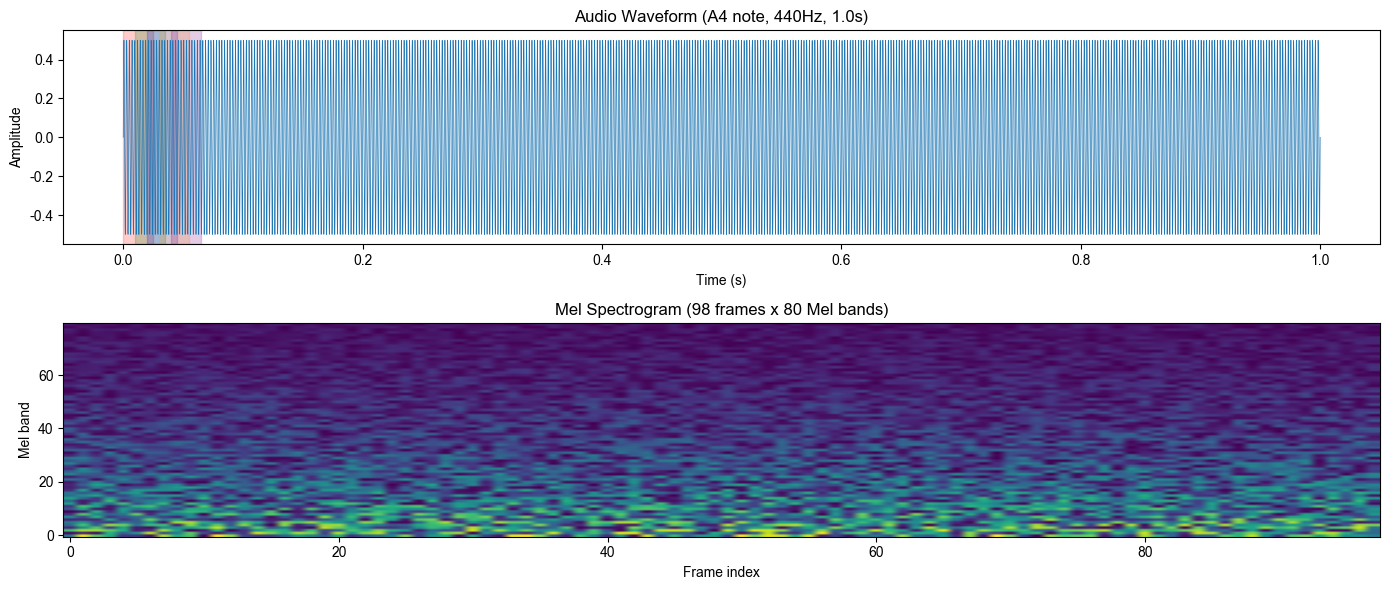


=== 音频分帧参数 ===
采样率: 16000 Hz
帧长: 25 ms (400 采样点)
帧移: 10 ms (160 采样点)
1 秒音频产生的帧数: 98

=== 音频 Token 数量估算 ===
    1秒音频 -> 98 帧 -> 经过声学模型后约 49~98 个音频 Token
    5秒音频 -> 490 帧 -> 经过声学模型后约 245~490 个音频 Token
   10秒音频 -> 980 帧 -> 经过声学模型后约 490~980 个音频 Token
   60秒音频 -> 5880 帧 -> 经过声学模型后约 2940~5880 个音频 Token

=== 对比: 同样 1 秒的内容 ===
  文本: ~5-10 个 Token
  图片 (3024x4032): ~11844 个视觉 Token
  音频: ~50-100 个音频 Token
  视频 (328x640, 13秒): ~2600 个视频 Token


In [2]:
sample_rate = 16000
frame_length = 25
frame_step = 10
duration_sec = 1.0

n_samples = int(sample_rate * duration_sec)
t = np.linspace(0, duration_sec, n_samples)
freq = 440
waveform = 0.5 * np.sin(2 * np.pi * freq * t)

frame_len_samples = int(sample_rate * frame_length / 1000)
frame_step_samples = int(sample_rate * frame_step / 1000)
n_frames = 1 + (n_samples - frame_len_samples) // frame_step_samples

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(t, waveform, linewidth=0.5)
axes[0].set_title(f"Audio Waveform (A4 note, {freq}Hz, {duration_sec}s)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

for i in range(min(5, n_frames)):
    start = i * frame_step_samples
    end = start + frame_len_samples
    axes[0].axvspan(start / sample_rate, end / sample_rate, alpha=0.2, color=['red', 'green', 'blue', 'orange', 'purple'][i])

n_mels = 80
np.random.seed(42)
mel_spec = np.random.rand(n_mels, n_frames) * 0.8
for f in range(n_mels):
    mel_spec[f, :] *= np.exp(-0.03 * f)

im = axes[1].imshow(mel_spec, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title(f"Mel Spectrogram ({n_frames} frames x {n_mels} Mel bands)")
axes[1].set_xlabel("Frame index")
axes[1].set_ylabel("Mel band")

plt.tight_layout()
plt.show()

print(f"\n=== 音频分帧参数 ===")
print(f"采样率: {sample_rate} Hz")
print(f"帧长: {frame_length} ms ({frame_len_samples} 采样点)")
print(f"帧移: {frame_step} ms ({frame_step_samples} 采样点)")
print(f"1 秒音频产生的帧数: {n_frames}")
print(f"\n=== 音频 Token 数量估算 ===")
for dur in [1, 5, 10, 60]:
    frames = dur * n_frames
    print(f"  {dur:>3d}秒音频 -> {frames} 帧 -> 经过声学模型后约 {frames // 2}~{frames} 个音频 Token")

print(f"\n=== 对比: 同样 1 秒的内容 ===")
print(f"  文本: ~5-10 个 Token")
print(f"  图片 (3024x4032): ~11844 个视觉 Token")
print(f"  音频: ~50-100 个音频 Token")
print(f"  视频 (328x640, 13秒): ~2600 个视频 Token")

### TTS：从 Token 生成语音

上面讲的是音频**输入**的过程（听懂声音）。那声音**输出**（说话）呢？这就是 TTS (Text-to-Speech) 的工作。

Qwen3.5-Omni 的语音生成流程：

1. **Thinker** 生成文本思维，决定"说什么"。
2. **Talker** 将文本映射为多层 Codebook 的音频 Token。
3. **ARIA 对齐**：动态对齐文本和语音的输出节奏，避免"机器人说话"的感觉。
4. **Codec 解码器** 将音频 Token 还原为波形，得到可播放的音频。

这里的关键技术是 **Residual Vector Quantization (RVQ)**：音频被编码为多层 Codebook 索引，第一层捕捉粗略的音频特征，后续层捕捉越来越细节的残差信息。这就像一张图片的"渐进式加载"：先看到模糊的轮廓，再逐步清晰。

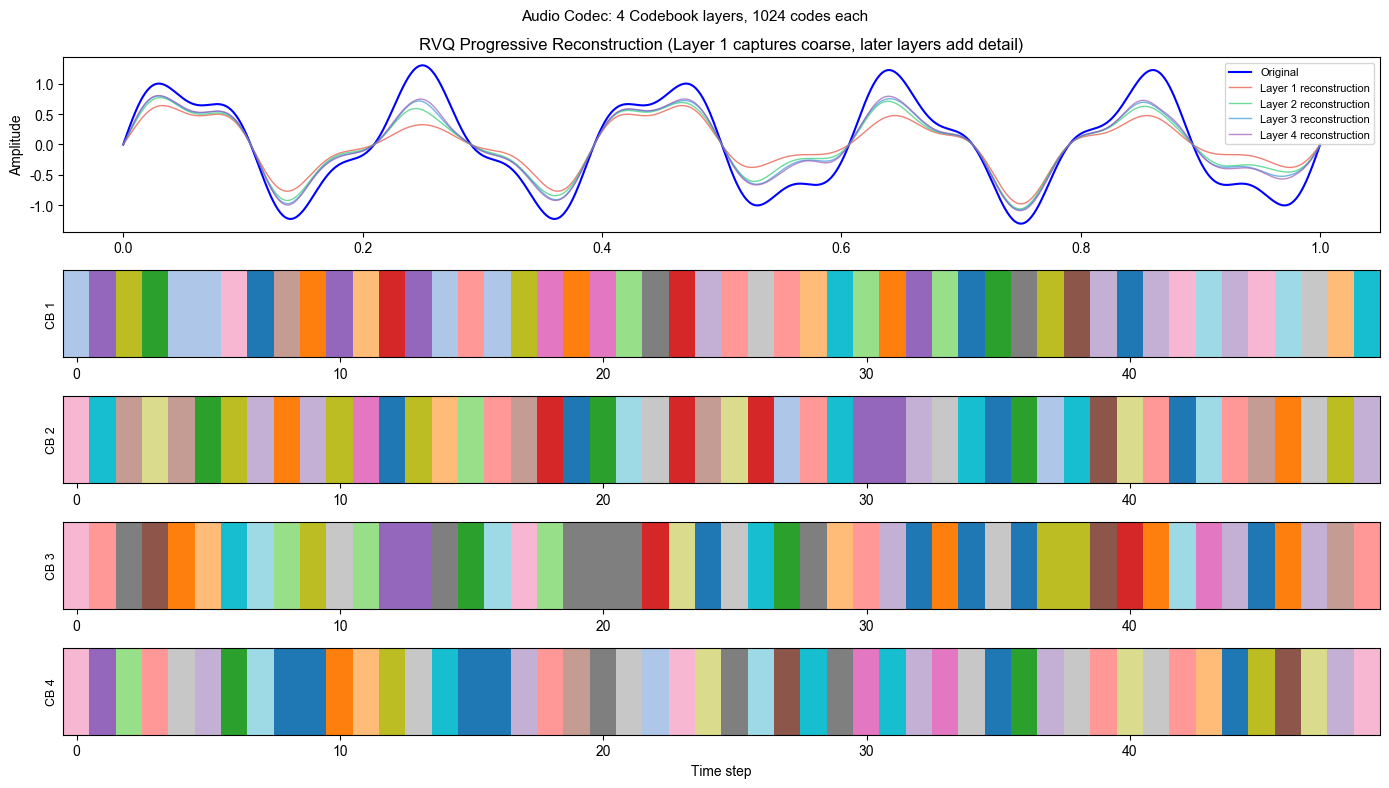


=== 音频 Codec 参数 ===
Codebook 层数: 4
每层码字数: 1024
总码字空间: 1099511627776 (理论上)
实际每个音频时间步的 Token 数: 4 个 Codebook 索引

对比文本 Token: 每个文本 Token 是 1 个 ID
对比音频 Token: 每个时间步需要 4 个 ID（多层 Codebook）


In [3]:
n_codebooks = 4
codebook_size = 1024
n_audio_tokens = 50

np.random.seed(42)
fig, axes = plt.subplots(n_codebooks + 1, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2] + [1]*n_codebooks})

t_audio = np.linspace(0, 1, 1000)
original = np.sin(2 * np.pi * 5 * t_audio) + 0.3 * np.sin(2 * np.pi * 13 * t_audio)
axes[0].plot(t_audio, original, 'b-', linewidth=1.5, label='Original')

reconstructed = np.zeros_like(original)
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
residuals = [original.copy()]
for layer in range(n_codebooks):
    approx = residuals[-1] * (0.5 ** (layer + 1)) * (1 + 0.5 * np.sin(2 * np.pi * (3 + layer * 7) * t_audio))
    reconstructed += approx
    residuals.append(original - reconstructed)
    axes[0].plot(t_audio, reconstructed, color=colors[layer], linewidth=1, alpha=0.7,
                 label=f'Layer {layer+1} reconstruction')

axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('RVQ Progressive Reconstruction (Layer 1 captures coarse, later layers add detail)')
axes[0].set_ylabel('Amplitude')

for layer in range(n_codebooks):
    codes = np.random.randint(0, codebook_size, n_audio_tokens)
    axes[layer + 1].imshow([codes], aspect='auto', cmap='tab20', interpolation='nearest')
    axes[layer + 1].set_ylabel(f'CB {layer+1}', fontsize=9)
    axes[layer + 1].set_yticks([])
    if layer == n_codebooks - 1:
        axes[layer + 1].set_xlabel('Time step')

plt.suptitle(f'Audio Codec: {n_codebooks} Codebook layers, {codebook_size} codes each', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n=== 音频 Codec 参数 ===")
print(f"Codebook 层数: {n_codebooks}")
print(f"每层码字数: {codebook_size}")
print(f"总码字空间: {codebook_size ** n_codebooks} (理论上)")
print(f"实际每个音频时间步的 Token 数: {n_codebooks} 个 Codebook 索引")
print(f"\n对比文本 Token: 每个文本 Token 是 1 个 ID")
print(f"对比音频 Token: 每个时间步需要 {n_codebooks} 个 ID（多层 Codebook）")

## 小结

本节我们深入探索了声音如何变成 Token：

| 方案 | 流程 | 适用场景 |
|------|------|---------|
| 声学特征 + 离散化 | 分帧 → Mel频谱 → 声学模型 → 离散Token | ASR（语音识别） |
| 端到端音频编解码器 | 编码器 → 多层Codebook → 解码器 | ASR + TTS（识别+合成） |

核心洞察：**音频 Token 的特殊之处在于多层 Codebook**。与文本 Token 每个时间步只需 1 个 ID 不同，音频 Token 每个时间步需要多个 Codebook 索引（通常 4 层），第一层捕捉粗略特征，后续层捕捉越来越细节的残差信息。

对比各模态 Token 数量（1秒内容）：
- 文本: ~5-10 个 Token
- 图片 (3024×4032): ~11844 个视觉 Token
- 音频: ~50-100 个音频 Token
- 视频 (328×640, 13秒): ~2600 个视频 Token

👉 下一节：[01-7 全双工多模态](./01-7-full_duplex_multimodal.ipynb)